Question 7 :: Shor's algorithm

In [12]:
    # controlled mod 15 unitary 

def c_amod15(a, power):
    """Controlled multiplication by a mod 15"""
    if a not in [2,4,7,8,11,13]:
        raise ValueError("’a’ must be 2,4,7,8,11 or 13")
    U = QuantumCircuit(4)
    for iteration in range(power):
        if a in [7,8]:
            U.swap(0,1)
            U.swap(1,2)
            U.swap(2,3)
        if a in [2,13]:
            U.swap(2,3)
            U.swap(1,2)
            U.swap(0,1)
        if a in [4,11]:
            U.swap(1,3)
            U.swap(0,2)
        if a in [7,11,13]:
            for q in range(4):
                U.x(q)
    U = U.to_gate()
    U.name = "%i^%i mod 15" % (a, power)
    c_U = U.control()
    return c_U

In [13]:
from qiskit import *

/var/folders/j9/hfdh_sw53n9_ttjj0vsyzs540000gn/T/ipykernel_33515/2101487960.py:30: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  shor.append(QFT(2*n).inverse(), i)


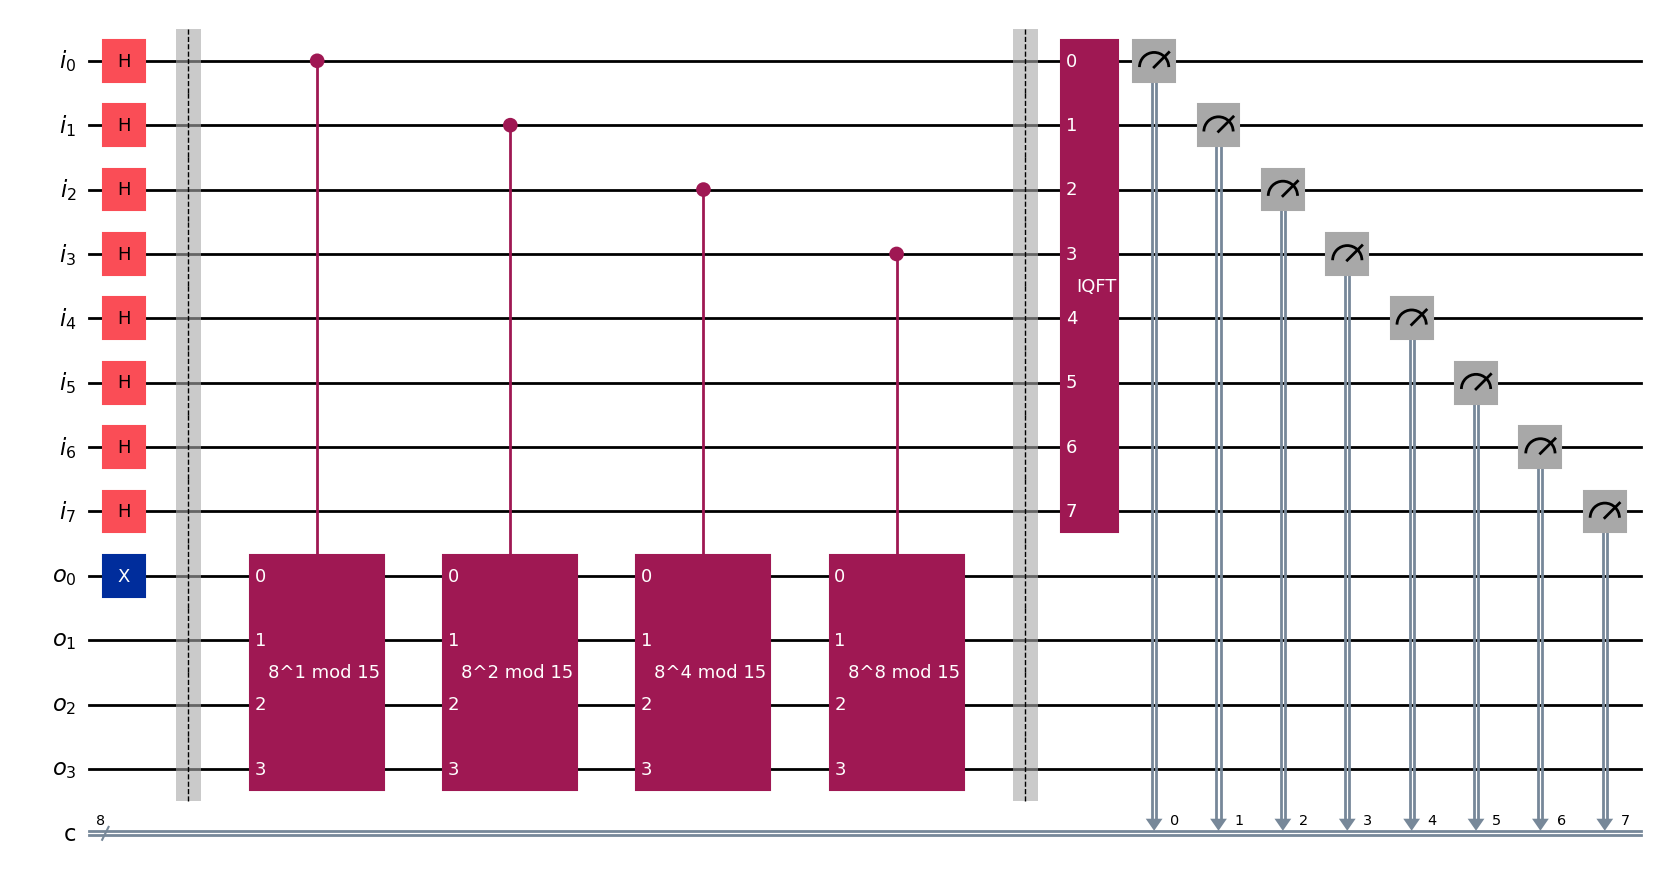

In [14]:
from qiskit.circuit.library import QFT

n = 4
a = 8

i = QuantumRegister(2*n, 'i')
o = QuantumRegister(n, 'o')
c = ClassicalRegister(2*n, 'c')

shor = QuantumCircuit(i, o, c)

for q in range(2*n):
    shor.h(i[q])

# initialize to |1> as the sum of the eigenkets over root r is the base state 1
shor.x(o[0])

shor.barrier()

# QPE

for power in range(n):
    qargs = [i[power], *o]
    shor.append(c_amod15(a, 2**power), qargs) 

shor.barrier()

# inverse QFT

shor.append(QFT(2*n).inverse(), i)

shor.measure(i, c)


shor.draw('mpl')


In [15]:
# sim it

from qiskit_aer.primitives import SamplerV2 as AerSampler
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_aer import AerSimulator

In [16]:
backend = AerSimulator()
sampler = AerSampler()

In [17]:

# Transpile the circuit for the simulator
pm = generate_preset_pass_manager(optimization_level=1, backend=backend)
shor_isa = pm.run(shor)

In [18]:
job_sim = sampler.run([shor_isa], shots=4096)
result_sim = job_sim.result()[0] # Get results for the first circuit

In [19]:

# Print the DataBin to see what's inside
list(result_sim.data.keys())

key = list(result_sim.data.keys())[0]
print(key)

c


In [20]:

counts_sim = result_sim.data[key].get_counts()
print(counts_sim)

{'11000000': 1049, '01000000': 1012, '00000000': 1020, '10000000': 1015}


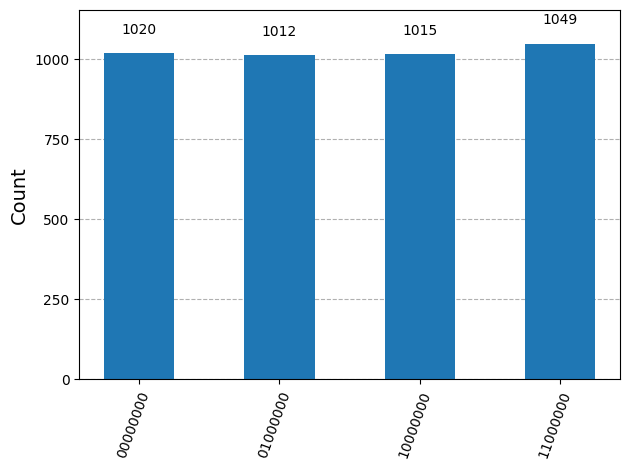

In [21]:

# Plot a histogram of the results
from qiskit.visualization import plot_histogram
plot_histogram(counts_sim)